# Statistical Anomaly Detection System

## Notebook 01: Data Collection and Initial Processing

### Purpose

This notebook loads and prepares a real-world multivariate dataset for anomaly detection analysis.

### Objectives

- Load dataset
- Inspect variables
- Assess data quality
- Prepare data for statistical analysis

### Expected Outcome

A cleaned and structured dataset suitable for robust statistical modeling and anomaly detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv(
    "Air Quality Data in India.csv",
    encoding="latin1",
    low_memory=False
)

print(df.shape)

df.head()

(260621, 13)


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


## Dataset Overview

The dataset contains historical air quality observations collected from monitoring stations across India.

The variables include pollutant concentrations, monitoring locations, and sampling dates.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260621 entries, 0 to 260620
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     175033 non-null  object 
 1   sampling_date                260621 non-null  object 
 2   state                        260621 non-null  object 
 3   location                     260620 non-null  object 
 4   agency                       171785 non-null  object 
 5   type                         257527 non-null  object 
 6   so2                          237793 non-null  float64
 7   no2                          249574 non-null  float64
 8   rspm                         235920 non-null  float64
 9   spm                          118350 non-null  float64
 10  location_monitoring_station  243683 non-null  object 
 11  pm2_5                        5078 non-null    float64
 12  date                         260617 non-null  object 
dtyp

In [4]:
df.columns

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

In [5]:
df.describe(include="all")

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
count,175033,260621,260621,260620,171785,257527,237793.000000,249574.000000,235920.000000,118350.000000,243683,5078.000000,260617
unique,439,5404,22,198,41,10,NaN,NaN,NaN,NaN,594,NaN,4990
top,193,19-03-15,Maharashtra,Guwahati,Maharashtra State Pollution Control Board,"Residential, Rural and other Areas",NaN,NaN,NaN,NaN,Regional Office,NaN,2015-03-19
freq,1428,156,60384,9984,27857,110138,NaN,NaN,NaN,NaN,2524,NaN,156
mean,NaN,NaN,NaN,NaN,NaN,NaN,11.307068,23.606797,96.122778,196.541292,NaN,37.762076,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,10.944105,16.459482,64.260570,133.671338,NaN,32.650556,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,4.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,4.300000,13.000000,54.000000,103.000000,NaN,23.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,19.900000,82.000000,173.000000,NaN,30.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,14.900000,30.000000,120.000000,257.000000,NaN,37.000000,NaN


## Missing Value Assessment

Missing values are common in environmental monitoring data and must be identified before further analysis.

In [6]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values

,0
pm2_5,255543
spm,142271
agency,88836
stn_code,85588
rspm,24701
so2,22828
location_monitoring_station,16938
no2,11047
type,3094
date,4


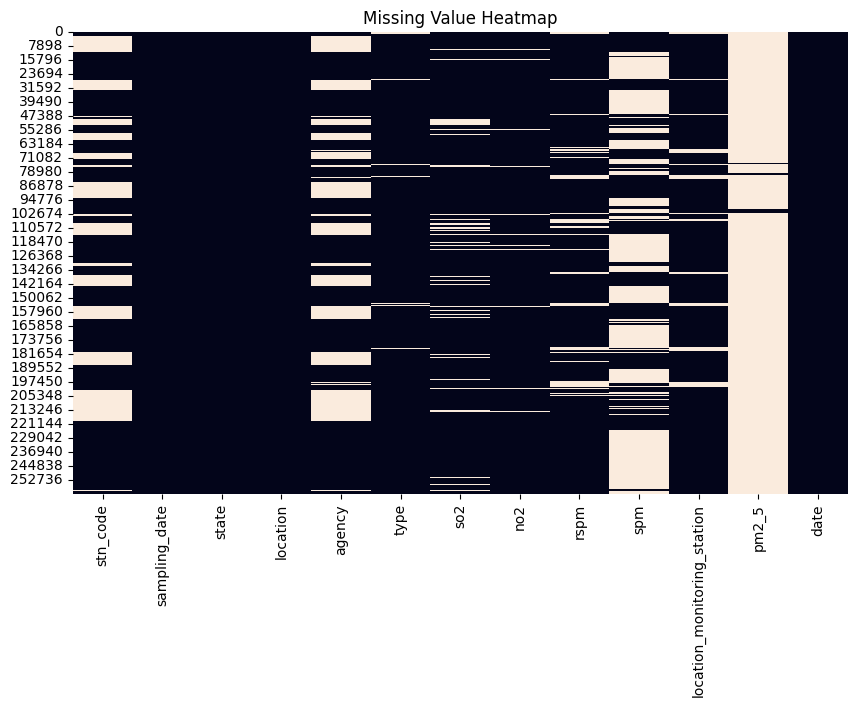

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title(
    "Missing Value Heatmap"
)

plt.savefig(
    "images/missing_values_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Selecting Numerical Variables

Anomaly detection methods require numerical features.

The pollutant concentration variables are extracted for analysis.

In [8]:
numeric_columns = [
    "so2",
    "no2",
    "rspm",
    "spm",
    "pm2_5"
]

air_quality = df[
    numeric_columns
].copy()

air_quality.head()

,so2,no2,rspm,spm,pm2_5
0,4.8,17.4,NaN,NaN,NaN
1,3.1,7.0,NaN,NaN,NaN
2,6.2,28.5,NaN,NaN,NaN
3,6.3,14.7,NaN,NaN,NaN
4,4.7,7.5,NaN,NaN,NaN


In [9]:
air_quality.describe()

,so2,no2,rspm,spm,pm2_5
count,237793.000000,249574.000000,235920.000000,118350.000000,5078.000000
mean,11.307068,23.606797,96.122778,196.541292,37.762076
std,10.944105,16.459482,64.260570,133.671338,32.650556
min,0.000000,0.000000,0.000000,0.000000,4.000000
25%,4.300000,13.000000,54.000000,103.000000,23.000000
50%,8.000000,19.900000,82.000000,173.000000,30.000000
75%,14.900000,30.000000,120.000000,257.000000,37.000000
max,597.000000,696.000000,1082.000000,2213.000000,395.000000


In [10]:
numeric_columns = [
    "so2",
    "no2",
    "rspm",
    "spm"
]

In [11]:
air_quality = df[numeric_columns].copy()

## Variable Selection

The PM2.5 variable contained an extremely large proportion of missing observations and was excluded from subsequent analysis.

The anomaly detection framework focuses on pollutant variables with sufficient observational coverage to ensure reliable statistical inference.

In [12]:
air_quality.describe()

,so2,no2,rspm,spm
count,237793.000000,249574.000000,235920.000000,118350.000000
mean,11.307068,23.606797,96.122778,196.541292
std,10.944105,16.459482,64.260570,133.671338
min,0.000000,0.000000,0.000000,0.000000
25%,4.300000,13.000000,54.000000,103.000000
50%,8.000000,19.900000,82.000000,173.000000
75%,14.900000,30.000000,120.000000,257.000000
max,597.000000,696.000000,1082.000000,2213.000000


## Handling Missing Values

Missing pollutant measurements are replaced using median imputation.

Median imputation is robust to extreme observations and is commonly used in environmental data analysis.

In [13]:
for column in air_quality.columns:

    air_quality[column] = (
        air_quality[column]
        .fillna(
            air_quality[column]
            .median()
        )
    )

air_quality.isnull().sum()

,0
so2,0
no2,0
rspm,0
spm,0


In [14]:
print(
    "Remaining Missing Values:",
    air_quality.isnull().sum().sum()
)

Remaining Missing Values: 0


In [15]:
air_quality.to_csv(
    "cleaned_air_quality.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.


## Findings

The air quality dataset was successfully loaded and examined.

Missing pollutant measurements were identified and addressed using median imputation.

The resulting dataset provides a clean and structured foundation for exploratory analysis, robust statistical modeling, and anomaly detection.

In [16]:
import os

print(os.listdir("images"))

['missing_values_heatmap.png']
